# Coverage-Guided Fuzz Test Input Generation (SuT: `MnistCNN`)

In this exercise, we'll explore coverage-guided fuzz test input generation for the MNIST CNN (`MnistCNN`)—building upon the approach from [01_traditional_coverage_guided_fuzzing.ipynb](./01_traditional_coverage_guided_fuzzing.ipynb).

In [28]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [29]:
# Load pre-saved MNIST model
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [30]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


In [31]:
from neuron_coverages import neuron_coverage, top_k_neuron_coverage
from mnist_instrumentation import forward_and_capture_relu

In [32]:
import torchvision.transforms.functional as TF

def gaussian_noise(image, std=0.1):
    """Add Gaussian noise to the image."""
    noise = torch.randn_like(image) * std
    return torch.clamp(image + noise, 0, 1)

def brightness_shift(image, max_shift=0.2):
    """Randomly shift brightness."""
    shift = (torch.rand(1).item() - 0.5) * 2 * max_shift  # [-max_shift, max_shift]
    return torch.clamp(image + shift, 0, 1)

def small_rotation(image, max_angle=20):
    """Apply small random rotation."""
    angle = (torch.rand(1).item() - 0.5) * 2 * max_angle  # [-max_angle, max_angle]
    # TF.rotate expects [C, H, W] format
    return TF.rotate(image, angle)

def pixel_dropout(image, dropout_rate=0.05):
    """Randomly drop pixels (set to 0)."""
    mask = torch.rand_like(image) > dropout_rate  # True = keep, False = drop
    return image * mask


# Define mutations
mutations = [
    ("Original", lambda x: x),
    ("Noise", gaussian_noise),
    ("Brightness", brightness_shift),
    ("Rotation", small_rotation),
    ("Dropout", pixel_dropout),
]

## Test Suite Mutation Guided by Neuron Coverage

In [33]:
# Coverage-guided test input mutation
# For each test input, select the mutation that maximizes coverage increase

# Track selected inputs and their mutation types
selected_inputs = []
selected_labels = []
mutation_choices = []

with torch.no_grad():
    for idx in range(len(test_images)):
        original_img = test_images[idx]
        label = test_labels[idx]
        
        # Get current coverage with selected inputs
        if len(selected_inputs) > 0:
            current_batch = torch.stack(selected_inputs).to(device)
            _, current_acts = forward_and_capture_relu(model, current_batch)
            current_cov, _ = neuron_coverage(current_acts)
        else:
            current_cov = 0.0
        
        # Try each mutation and find the best one
        best_cov = current_cov
        best_img = original_img
        best_mutation = "Original"
        
        for name, mutation_fn in mutations:
            mutated_img = mutation_fn(original_img.clone())
            
            # Calculate coverage with this candidate added
            if len(selected_inputs) > 0:
                candidate_batch = torch.stack(selected_inputs + [mutated_img]).to(device)
            else:
                candidate_batch = mutated_img.unsqueeze(0).to(device)
            
            _, candidate_acts = forward_and_capture_relu(model, candidate_batch)
            candidate_cov, _ = neuron_coverage(candidate_acts)
            
            if candidate_cov > best_cov:
                best_cov = candidate_cov
                best_img = mutated_img
                best_mutation = name
        
        # Add the best input to our selected set
        selected_inputs.append(best_img)
        selected_labels.append(label)
        mutation_choices.append(best_mutation)

# Convert to tensor
selected_inputs_tensor = torch.stack(selected_inputs)

print(f"Selected {len(selected_inputs)} test inputs")
print(f"\nMutation distribution:")
for name, _ in mutations:
    count = mutation_choices.count(name)
    print(f"  - {name}: {count} ({100*count/len(mutation_choices):.1f}%)")


Selected 200 test inputs

Mutation distribution:
  - Original: 191 (95.5%)
  - Noise: 2 (1.0%)
  - Brightness: 2 (1.0%)
  - Rotation: 5 (2.5%)
  - Dropout: 0 (0.0%)


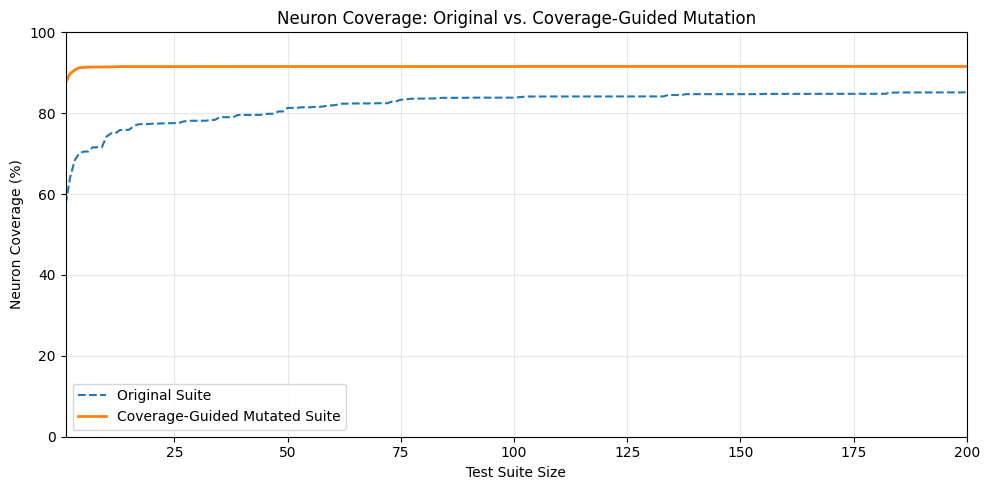

Coverage comparison:
  Final - Original: 85.2%, Mutated: 91.6% (Δ +6.4%)

Coverage at key points:
  Size  10: Original 74.2% → Mutated 91.4% (Δ +17.2%)
  Size  50: Original 81.3% → Mutated 91.5% (Δ +10.2%)
  Size 100: Original 83.8% → Mutated 91.5% (Δ +7.7%)
  Size 200: Original 85.2% → Mutated 91.6% (Δ +6.4%)


In [34]:
# Calculate and visualize neuron coverage: Original vs Coverage-Guided Mutated Suite
import matplotlib.pyplot as plt

max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))

# Calculate coverages for both suites
original_coverages = []
mutated_coverages = []

with torch.no_grad():
    for size in batch_sizes:
        # Original suite coverage
        orig_batch = test_images[:size].to(device)
        _, orig_acts = forward_and_capture_relu(model, orig_batch)
        orig_cov, _ = neuron_coverage(orig_acts)
        original_coverages.append(orig_cov)
        
        # Mutated suite coverage
        mut_batch = selected_inputs_tensor[:size].to(device)
        _, mut_acts = forward_and_capture_relu(model, mut_batch)
        mut_cov, _ = neuron_coverage(mut_acts)
        mutated_coverages.append(mut_cov)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [c * 100 for c in original_coverages], 
         linestyle="--", linewidth=1.5, color="tab:blue", label="Original Suite")
plt.plot(batch_sizes, [c * 100 for c in mutated_coverages], 
         linestyle="-", linewidth=2, color="tab:orange", label="Coverage-Guided Mutated Suite")
plt.xlabel("Test Suite Size")
plt.ylabel("Neuron Coverage (%)")
plt.title("Neuron Coverage: Original vs. Coverage-Guided Mutation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Print summary
print("Coverage comparison:")
print(f"  Final - Original: {original_coverages[-1]:.1%}, Mutated: {mutated_coverages[-1]:.1%} (Δ {mutated_coverages[-1]-original_coverages[-1]:+.1%})")

print("\nCoverage at key points:")
for size in [10, 50, 100, 200]:
    if size <= max_size:
        idx = size - 1
        orig = original_coverages[idx]
        mut = mutated_coverages[idx]
        print(f"  Size {size:3d}: Original {orig:.1%} → Mutated {mut:.1%} (Δ {mut-orig:+.1%})")


## Test Suite Mutation Guided by Top-K Neuron Coverage

In [35]:
# Top-K Coverage-guided test input mutation
# For each test input, select the mutation that maximizes top-k neuron coverage increase

K_RATIO = 0.1  # Top 10%

# Track selected inputs and their mutation types
topk_selected_inputs = []
topk_selected_labels = []
topk_mutation_choices = []

with torch.no_grad():
    for idx in range(len(test_images)):
        original_img = test_images[idx]
        label = test_labels[idx]
        
        # Get current top-k coverage with selected inputs
        if len(topk_selected_inputs) > 0:
            current_batch = torch.stack(topk_selected_inputs).to(device)
            _, current_acts = forward_and_capture_relu(model, current_batch)
            current_cov, _ = top_k_neuron_coverage(current_acts, k=K_RATIO)
        else:
            current_cov = 0.0
        
        # Try each mutation and find the best one
        best_cov = current_cov
        best_img = original_img
        best_mutation = "Original"
        
        for name, mutation_fn in mutations:
            mutated_img = mutation_fn(original_img.clone())
            
            # Calculate top-k coverage with this candidate added
            if len(topk_selected_inputs) > 0:
                candidate_batch = torch.stack(topk_selected_inputs + [mutated_img]).to(device)
            else:
                candidate_batch = mutated_img.unsqueeze(0).to(device)
            
            _, candidate_acts = forward_and_capture_relu(model, candidate_batch)
            candidate_cov, _ = top_k_neuron_coverage(candidate_acts, k=K_RATIO)
            
            if candidate_cov > best_cov:
                best_cov = candidate_cov
                best_img = mutated_img
                best_mutation = name
        
        # Add the best input to our selected set
        topk_selected_inputs.append(best_img)
        topk_selected_labels.append(label)
        topk_mutation_choices.append(best_mutation)

# Convert to tensor
topk_selected_inputs_tensor = torch.stack(topk_selected_inputs)

print(f"Selected {len(topk_selected_inputs)} test inputs (Top-{K_RATIO:.0%} guided)")
print(f"\nMutation distribution:")
for name, _ in mutations:
    count = topk_mutation_choices.count(name)
    print(f"  - {name}: {count} ({100*count/len(topk_mutation_choices):.1f}%)")


Selected 200 test inputs (Top-10% guided)

Mutation distribution:
  - Original: 76 (38.0%)
  - Noise: 42 (21.0%)
  - Brightness: 7 (3.5%)
  - Rotation: 49 (24.5%)
  - Dropout: 26 (13.0%)


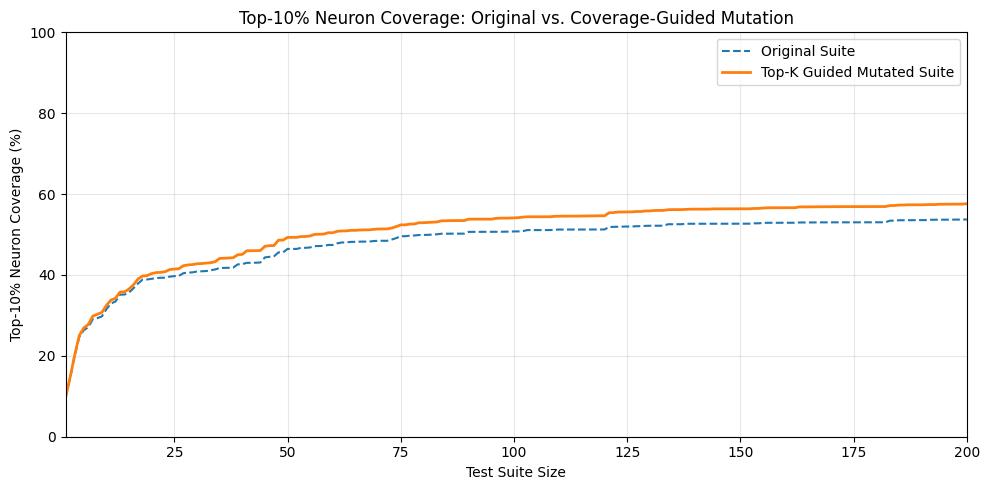

Top-10% Coverage comparison:
  Final - Original: 53.7%, Mutated: 57.6% (Δ +3.9%)

Coverage at key points:
  Size  10: Original 31.5% → Mutated 32.5% (Δ +0.9%)
  Size  50: Original 46.4% → Mutated 49.3% (Δ +2.8%)
  Size 100: Original 50.8% → Mutated 54.1% (Δ +3.4%)
  Size 200: Original 53.7% → Mutated 57.6% (Δ +3.9%)


In [36]:
# Calculate and visualize Top-K neuron coverage: Original vs Coverage-Guided Mutated Suite

max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))

# Calculate top-k coverages for both suites
topk_original_coverages = []
topk_mutated_coverages = []

with torch.no_grad():
    for size in batch_sizes:
        # Original suite coverage
        orig_batch = test_images[:size].to(device)
        _, orig_acts = forward_and_capture_relu(model, orig_batch)
        orig_cov, _ = top_k_neuron_coverage(orig_acts, k=K_RATIO)
        topk_original_coverages.append(orig_cov)
        
        # Top-K guided mutated suite coverage
        mut_batch = topk_selected_inputs_tensor[:size].to(device)
        _, mut_acts = forward_and_capture_relu(model, mut_batch)
        mut_cov, _ = top_k_neuron_coverage(mut_acts, k=K_RATIO)
        topk_mutated_coverages.append(mut_cov)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [c * 100 for c in topk_original_coverages], 
         linestyle="--", linewidth=1.5, color="tab:blue", label="Original Suite")
plt.plot(batch_sizes, [c * 100 for c in topk_mutated_coverages], 
         linestyle="-", linewidth=2, color="tab:orange", label="Top-K Guided Mutated Suite")
plt.xlabel("Test Suite Size")
plt.ylabel(f"Top-{K_RATIO:.0%} Neuron Coverage (%)")
plt.title(f"Top-{K_RATIO:.0%} Neuron Coverage: Original vs. Coverage-Guided Mutation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Print summary
print(f"Top-{K_RATIO:.0%} Coverage comparison:")
print(f"  Final - Original: {topk_original_coverages[-1]:.1%}, Mutated: {topk_mutated_coverages[-1]:.1%} (Δ {topk_mutated_coverages[-1]-topk_original_coverages[-1]:+.1%})")

print("\nCoverage at key points:")
for size in [10, 50, 100, 200]:
    if size <= max_size:
        idx = size - 1
        orig = topk_original_coverages[idx]
        mut = topk_mutated_coverages[idx]
        print(f"  Size {size:3d}: Original {orig:.1%} → Mutated {mut:.1%} (Δ {mut-orig:+.1%})")


## 🧪 Hands-on: How Do Image Mutations Change Coverage?

In the Module 04 exercise *(04_neuron_coverages_exercise.ipynb → "🏆 Challenge: Manual Test Optimization")*
you hand-picked **20 test inputs** to maximize Top-10% Neuron Coverage.

Here we reuse **those same 20 inputs** and ask a different question:

> If I **mutate** those 20 images, does the *mutated* suite cover **more** or **fewer** neurons than the original?

You will apply **7 image mutations** to your 20 inputs and let the harness measure
**Neuron Coverage** and **Top-10% Neuron Coverage** for each — every result compared
against the *original (un-mutated)* 20 inputs.

### ✍️ What you fill in
1. **Your 20 indices** — paste the list you chose in the Module 04 challenge → `MY_20_INDICES`.
2. **3 mutation functions** — only the function *body*:
   - `contrast_scale(image, factor)` — name & signature given
   - `image_translation(image, max_shift)` — name & signature given
   - `my_mutation(image)` — **your own** mutation, design it freely!

The other 4 mutations (`gaussian_noise`, `brightness_shift`, `small_rotation`, `pixel_dropout`)
are already defined earlier in this notebook and reused here, for **7 mutations total**.

### ▶️ What the harness does (just run it)
Applies each of the 7 mutations to your 20 inputs, then prints **two tables**
— one for Neuron Coverage, one for Top-10% Neuron Coverage — showing each mutation's
coverage next to its **Δ vs. the original** suite (how much it increased / decreased).

In [37]:
# ============================================================
# TODO 1 — Paste YOUR 20 indices from the Module 04 challenge
#   (04_neuron_coverages_exercise.ipynb →
#    "🏆 Challenge: Manual Test Optimization", your `select_test_indices()`)
# ------------------------------------------------------------
# Must be EXACTLY 20 distinct indices, each in 0..199.
# ============================================================

MY_20_INDICES = list(range(20))   # <-- TODO: replace with the 20 indices you chose in Module 04

print(f"{len(MY_20_INDICES)} indices selected:", MY_20_INDICES)

20 indices selected: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [38]:
# ============================================================
# TODO 2 — Implement 3 more mutation operators (fill in the body only)
# ------------------------------------------------------------
# Each mutation takes ONE image tensor of shape [1, 28, 28] (values in [0, 1])
# and returns a mutated image of the SAME shape. Always clamp back into [0, 1].
# (TF = torchvision.transforms.functional, already imported above.)
# ============================================================

def contrast_scale(image, factor=1.5):
    """Increase / decrease contrast by scaling pixels around the image mean.
    factor > 1 -> more contrast, factor < 1 -> less contrast.
    Hint:  out = (image - mean) * factor + mean , then clamp to [0, 1].
    """
    # TODO: implement and return the mutated image
    return image


def image_translation(image, max_shift=3):
    """Randomly shift (translate) the image by up to `max_shift` pixels in x and y.
    Hint:  pick random integers dx, dy in [-max_shift, max_shift], then
           TF.affine(image, angle=0, translate=[dx, dy], scale=1.0, shear=0).
    """
    # TODO: implement and return the mutated image
    return image


def my_mutation(image):
    """YOUR own custom mutation — be creative!
    Ideas: blur, invert intensities, occlude a patch, erosion/dilation, shear, ...
    """
    # TODO: implement and return the mutated image
    return image


# All 7 mutation operators used by the experiment below.
# (gaussian_noise / brightness_shift / small_rotation / pixel_dropout were defined earlier.)
mutation_operators = [
    ("gaussian_noise",    gaussian_noise),
    ("brightness_shift",  brightness_shift),
    ("small_rotation",    small_rotation),
    ("pixel_dropout",     pixel_dropout),
    ("contrast_scale",    contrast_scale),
    ("image_translation", image_translation),
    ("my_mutation",       my_mutation),
]
print(f"{len(mutation_operators)} mutation operators ready:",
      ", ".join(n for n, _ in mutation_operators))

7 mutation operators ready: gaussian_noise, brightness_shift, small_rotation, pixel_dropout, contrast_scale, image_translation, my_mutation


In [39]:
# ----------------- experiment harness (given — just run it) -----------------
import pandas as pd
from IPython.display import display

K_RATIO = 0.1   # Top-10% neuron coverage

# --- sanity-check the pasted indices ---
sel = [int(i) for i in MY_20_INDICES]
problems = []
if len(sel) != 20:
    problems.append(f"need exactly 20 indices, got {len(sel)}")
if len(set(sel)) != len(sel):
    problems.append("indices must be distinct (duplicates found)")
if any(i < 0 or i > 199 for i in sel):
    problems.append("every index must be in 0..199")
if problems:
    print("⚠️  Check MY_20_INDICES:")
    for p in problems:
        print("   -", p)

# --- the original (un-mutated) 20-input suite ---
original_suite = test_images[torch.as_tensor(sel, dtype=torch.long)]


def coverage_of(images):
    """Return (neuron_coverage, top_k_neuron_coverage) for a batch of images."""
    with torch.no_grad():
        _, acts = forward_and_capture_relu(model, images.to(device))
    nc, _ = neuron_coverage(acts)
    tkc, _ = top_k_neuron_coverage(acts, k=K_RATIO, per_filter=True)
    return nc, tkc


def mutate_suite(mutation_fn, images, seed=123):
    """Apply a mutation to every image in the suite (re-seeded for reproducibility)."""
    torch.manual_seed(seed)
    return torch.stack([mutation_fn(img.clone()) for img in images])


# --- measure the original suite, then each of the 7 mutated suites ---
orig_nc, orig_tkc = coverage_of(original_suite)

nc_rows  = [("Original (no mutation)", orig_nc, None)]
tkc_rows = [("Original (no mutation)", orig_tkc, None)]

for name, fn in mutation_operators:
    mutated_suite = mutate_suite(fn, original_suite)
    nc, tkc = coverage_of(mutated_suite)
    nc_rows.append((name, nc, nc - orig_nc))
    tkc_rows.append((name, tkc, tkc - orig_tkc))


# --- build the two comparison tables (coverage + Δ vs. original) ---
def build_table(rows, metric_label):
    return pd.DataFrame(
        {
            metric_label:    [f"{100 * cov:.2f}%" for _, cov, _ in rows],
            "Δ vs Original": ["—" if d is None else f"{100 * d:+.2f}%p" for _, _, d in rows],
        },
        index=[name for name, _, _ in rows],
    )


nc_table  = build_table(nc_rows,  "Neuron Coverage")
tkc_table = build_table(tkc_rows, "Top-10% Neuron Coverage")

print("=== Neuron Coverage:  original 20 inputs vs. 7 mutations ===")
display(nc_table)
print("\n=== Top-10% Neuron Coverage:  original 20 inputs vs. 7 mutations ===")
display(tkc_table)

=== Neuron Coverage:  original 20 inputs vs. 7 mutations ===


,Neuron Coverage,Δ vs Original
Original (no mutation),77.40%,—
gaussian_noise,90.81%,+13.40%p
brightness_shift,91.51%,+14.11%p
small_rotation,78.47%,+1.07%p
pixel_dropout,77.31%,-0.10%p
contrast_scale,77.40%,+0.00%p
image_translation,77.40%,+0.00%p
my_mutation,77.40%,+0.00%p



=== Top-10% Neuron Coverage:  original 20 inputs vs. 7 mutations ===


,Top-10% Neuron Coverage,Δ vs Original
Original (no mutation),39.05%,—
gaussian_noise,39.59%,+0.54%p
brightness_shift,39.06%,+0.01%p
small_rotation,40.18%,+1.13%p
pixel_dropout,39.05%,+0.00%p
contrast_scale,39.05%,+0.00%p
image_translation,39.05%,+0.00%p
my_mutation,39.05%,+0.00%p


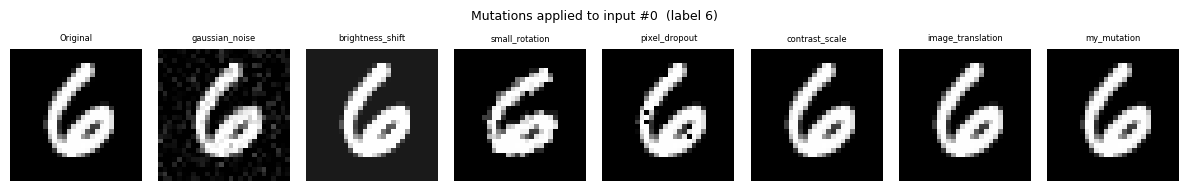

In [40]:
# (bonus) Visualize every mutation on one of your inputs.
# Handy to confirm your 3 new functions — especially my_mutation — actually change the image.
sample = original_suite[0]
torch.manual_seed(123)
panel = [("Original", sample)] + [(name, fn(sample.clone())) for name, fn in mutation_operators]

fig, axes = plt.subplots(1, len(panel), figsize=(len(panel) * 1.5, 1.9))
for ax, (name, img) in zip(axes, panel):
    ax.imshow(img.detach().squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(name, fontsize=6)
    ax.axis("off")
fig.suptitle(f"Mutations applied to input #{sel[0]}  (label {test_labels[sel[0]].item()})", fontsize=9)
plt.tight_layout()
plt.show()